In [3]:
from IPython.display import Image

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [5]:
device = 'cuda:3'
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    device_map={"": device}  
)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.
Loading checkpoint shards: 100%|████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.83it/s]


In [6]:
model.num_parameters()

3085938688

In [5]:
# for name, param in model.named_parameters():
#     print(f"{name:80}  |  shape: {tuple(param.shape)}")

In [7]:
# model.state_dict()

In [7]:
# 可以直接 cpu()
# 否则 需要先 detach().cpu()
model.state_dict()["model.layers.27.mlp.up_proj.weight"].requires_grad

False

In [8]:
weight = model.state_dict()["model.layers.27.mlp.up_proj.weight"].cpu().numpy()

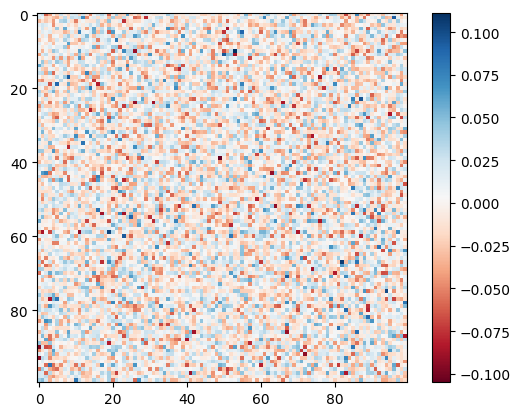

In [9]:
import matplotlib.pyplot as plt
plt.imshow(weight[:100, :100], cmap="RdBu")
plt.colorbar()

### embedding table

In [26]:
input_embedding = model.state_dict()["model.embed_tokens.weight"].cpu().numpy()
input_embedding.shape

(151936, 2048)

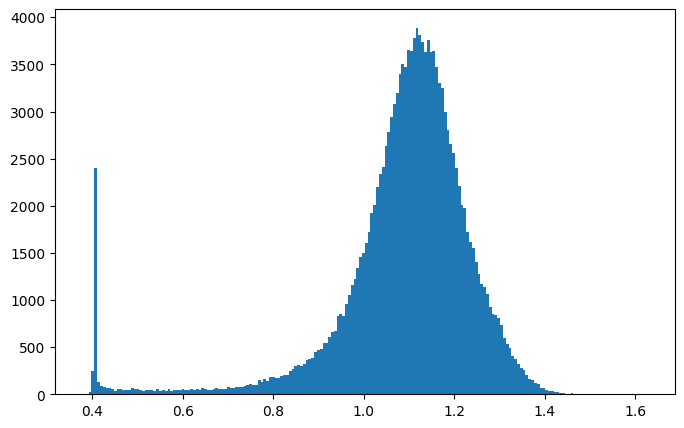

In [31]:
import numpy as np
norms = np.linalg.norm(input_embedding, axis=1).astype(np.float32) 
plt.figure(figsize=(8, 5))
_ = plt.hist(norms, bins=200)

In [11]:
tokenizer.encode('王')

[99445]

In [12]:
top_k = 20 

token = input('input a token：') 

token_id = tokenizer.encode(token)[0]
print("token id 是 ",token_id)
embbeding = [input_embedding[token_id]]

from sklearn.metrics.pairwise import cosine_similarity
sims = cosine_similarity(embbeding, input_embedding)[0]

nearest = sims.argsort()[::-1][1: top_k+1] #排除自己本身
print(f'和 {token} 最相近的 {top_k} 个 token：')
for idx in nearest:
  print(f'{tokenizer.decode(idx)} (score: {sims[idx]:.4f})')

input a token： 王


token id 是  99445
和 王 最相近的 20 个 token：
 King (score: 0.5865)
 king (score: 0.5286)
King (score: 0.4801)
 Vương (score: 0.4260)
 kings (score: 0.4254)
 KING (score: 0.4165)
 Kings (score: 0.4056)
 Wang (score: 0.3742)
国王 (score: 0.3698)
 W (score: 0.3502)
왕 (score: 0.3359)
王国 (score: 0.3355)
王先生 (score: 0.3124)
王者 (score: 0.3122)
王子 (score: 0.3081)
_W (score: 0.3077)
王府 (score: 0.3060)
king (score: 0.3013)
王某 (score: 0.2991)
W (score: 0.2814)


### representation of each layer

In [23]:
Image(url='./figs/representation.png', width=400)

In [13]:
inputs = tokenizer.encode("大家好", return_tensors="pt").to(device)

print("encoded Token IDs：", inputs)

# output_hidden_states=True 才会返回每一层的 representation (hidden states)
outputs = model(inputs, output_hidden_states=True) 

hidden_states = outputs.hidden_states
# hidden_states[0] -> embedding （把 token 转成 token embedding 的结果)
# hidden_states[1] ~ hidden_states[N] -> 每一个 Transformer block 的輸出
print(f"一共拿到 {len(hidden_states)} 层 representation（包含 token embedding）。")

# 列出每层输出的形狀
for idx, h in enumerate(hidden_states):
    print(f"Layer {idx:2d} 输出 shape: {h.shape}")
    # h.shape = [batch_size, seq_len, hidden_size]

print("\n=== Token Embedding 输出 ===")
print(hidden_states[0])

print("\n=== 第一个Transformer Layer 的输出 ===")
print(hidden_states[1])

encoded Token IDs： tensor([[99466, 52801]], device='cuda:3')
一共拿到 37 层 representation（包含 token embedding）。
Layer  0 输出 shape: torch.Size([1, 2, 2048])
Layer  1 输出 shape: torch.Size([1, 2, 2048])
Layer  2 输出 shape: torch.Size([1, 2, 2048])
Layer  3 输出 shape: torch.Size([1, 2, 2048])
Layer  4 输出 shape: torch.Size([1, 2, 2048])
Layer  5 输出 shape: torch.Size([1, 2, 2048])
Layer  6 输出 shape: torch.Size([1, 2, 2048])
Layer  7 输出 shape: torch.Size([1, 2, 2048])
Layer  8 输出 shape: torch.Size([1, 2, 2048])
Layer  9 输出 shape: torch.Size([1, 2, 2048])
Layer 10 输出 shape: torch.Size([1, 2, 2048])
Layer 11 输出 shape: torch.Size([1, 2, 2048])
Layer 12 输出 shape: torch.Size([1, 2, 2048])
Layer 13 输出 shape: torch.Size([1, 2, 2048])
Layer 14 输出 shape: torch.Size([1, 2, 2048])
Layer 15 输出 shape: torch.Size([1, 2, 2048])
Layer 16 输出 shape: torch.Size([1, 2, 2048])
Layer 17 输出 shape: torch.Size([1, 2, 2048])
Layer 18 输出 shape: torch.Size([1, 2, 2048])
Layer 19 输出 shape: torch.Size([1, 2, 2048])
Layer 20 输出 s

In [14]:
def get_embedding(text, layer_num):
    print(f"\n=== {text} ===")

    inputs = tokenizer.encode(text, return_tensors="pt", add_special_tokens=False).to(device)
    #print(inputs)

    outputs = model(inputs, output_hidden_states=True)
    hidden_states = outputs.hidden_states
    hidden_states_layer = hidden_states[layer_num]

    tokens = tokenizer.tokenize(text)
    seq_length = len(tokens)
    for t in range(0,seq_length):
      print(tokens[t], ":", hidden_states_layer[0][t])

In [15]:
layer_num = 10 # 0: token embedding, >0: contextualized token embedding
get_embedding("How about you?", layer_num )
get_embedding("How are you?", layer_num )
get_embedding("Nice to meet you.", layer_num )


=== How about you? ===
How : tensor([ 3.3118, -0.5591, -1.4252,  ...,  1.8726, -0.4414, -2.1208],
       device='cuda:3', grad_fn=<SelectBackward0>)
Ġabout : tensor([-0.1690,  0.1751,  0.1836,  ..., -1.7530, -0.2627, -0.0105],
       device='cuda:3', grad_fn=<SelectBackward0>)
Ġyou : tensor([ 0.6858, -0.5115,  1.3142,  ..., -0.2132, -2.6446, -0.9225],
       device='cuda:3', grad_fn=<SelectBackward0>)
? : tensor([-0.0740,  0.6665,  1.7291,  ...,  0.4819, -0.6315, -0.6735],
       device='cuda:3', grad_fn=<SelectBackward0>)

=== How are you? ===
How : tensor([ 3.3118, -0.5591, -1.4252,  ...,  1.8726, -0.4414, -2.1208],
       device='cuda:3', grad_fn=<SelectBackward0>)
Ġare : tensor([ 1.0463,  0.0259, -1.0642,  ..., -0.8256, -1.9191,  0.7281],
       device='cuda:3', grad_fn=<SelectBackward0>)
Ġyou : tensor([ 1.6389, -0.2631,  0.7387,  ...,  0.9081, -1.6781,  0.3291],
       device='cuda:3', grad_fn=<SelectBackward0>)
? : tensor([ 1.6282,  0.5158, -0.1412,  ...,  1.2469, -1.5713,  1.23

In [16]:
#比較 sentence1 和 sentence2 中的 "apple" ，在不同層的相似程度

sentence1 = "I ate an apple for breakfast."
sentence2 = "The company that brought us the iPad and AirPods is apple."

In [17]:
inputs1 = tokenizer.encode(sentence1,return_tensors="pt").to(device)
print(inputs1[0])
for idx, token in enumerate(inputs1[0]):
    print(idx, token, tokenizer.decode(token))

inputs2 = tokenizer.encode(sentence2,return_tensors="pt").to(device)
print(inputs2[0])
for idx, token in enumerate(inputs2[0]):
    print(idx, token, tokenizer.decode(token))

tensor([   40, 29812,   458, 23268,   369, 17496,    13], device='cuda:3')
0 tensor(40, device='cuda:3') I
1 tensor(29812, device='cuda:3')  ate
2 tensor(458, device='cuda:3')  an
3 tensor(23268, device='cuda:3')  apple
4 tensor(369, device='cuda:3')  for
5 tensor(17496, device='cuda:3')  breakfast
6 tensor(13, device='cuda:3') .
tensor([  785,  2813,   429,  7117,   601,   279, 22271,   323,  6553, 23527,
           82,   374, 23268,    13], device='cuda:3')
0 tensor(785, device='cuda:3') The
1 tensor(2813, device='cuda:3')  company
2 tensor(429, device='cuda:3')  that
3 tensor(7117, device='cuda:3')  brought
4 tensor(601, device='cuda:3')  us
5 tensor(279, device='cuda:3')  the
6 tensor(22271, device='cuda:3')  iPad
7 tensor(323, device='cuda:3')  and
8 tensor(6553, device='cuda:3')  Air
9 tensor(23527, device='cuda:3') Pod
10 tensor(82, device='cuda:3') s
11 tensor(374, device='cuda:3')  is
12 tensor(23268, device='cuda:3')  apple
13 tensor(13, device='cuda:3') .


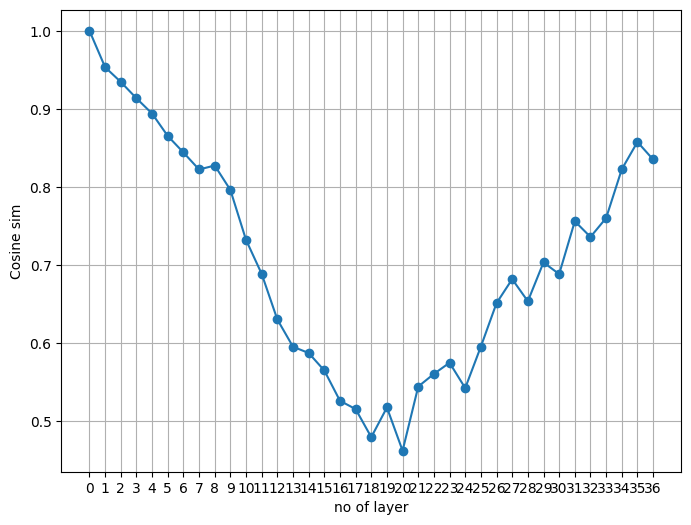

In [18]:
idx1 = 3 # apple 在 "I ate an apple for breakfast." 的位置
idx2 = 12 # apple 在 "The tech company apple announced its earnings yesterday." 的位置
#[128000, 791, 2883, 430, 7263, 603,  279, 23067, 323, 6690, 24434, 82,374,  24149, 13]

inputs1 = tokenizer.encode(sentence1,return_tensors="pt").to(device)
outputs1 = model(inputs1, output_hidden_states=True)
hidden_states1 = outputs1.hidden_states

inputs2 = tokenizer.encode(sentence2,return_tensors="pt").to(device)
outputs2 = model(inputs2, output_hidden_states=True)
hidden_states2 = outputs2.hidden_states

distances = []
for l in range(len(hidden_states)):
    vec1 = hidden_states1[l][0][idx1].detach().cpu().numpy()  # 句子1 中 '▁apple' 的向量
    vec2 = hidden_states2[l][0][idx2].detach().cpu().numpy()  # 句子2 中 '▁apple' 的向量
    cos_sim = cosine_similarity([vec1], [vec2])[0]
    #print(cos_sim)
    distances.append(cos_sim)


layers = list(range(len(distances)))
plt.figure(figsize=(8, 6))
plt.plot(layers, distances, marker='o')
plt.xticks(layers)
plt.xlabel("no of layer")
plt.ylabel("Cosine sim")
plt.grid(True)

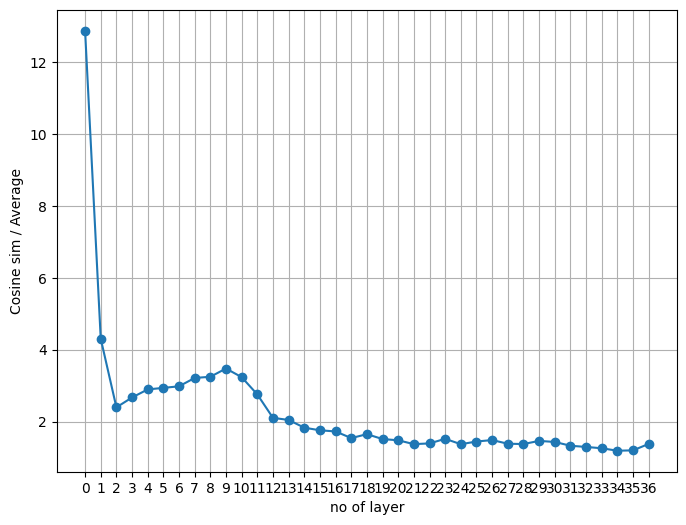

In [19]:
sentence1 = "I ate an apple for breakfast."
sentence2 = "The company that brought us the iPad and AirPods is apple."

inputs1 = tokenizer.encode(sentence1, return_tensors="pt").to(device)
outputs1 = model(inputs1, output_hidden_states=True)
hidden_states1 = outputs1.hidden_states

inputs2 = tokenizer.encode(sentence2, return_tensors="pt").to(device)
outputs2 = model(inputs2, output_hidden_states=True)
hidden_states2 = outputs2.hidden_states

distances = []
for l in range(len(hidden_states)):
    layer_hidden_states1 = hidden_states1[l][0].detach().cpu().numpy() # Shape: [seq_len1, hidden_size]
    layer_hidden_states2 = hidden_states2[l][0].detach().cpu().numpy() # Shape: [seq_len2, hidden_size]
    # Calculate pairwise cosine similarity between all tokens in sentence1 and sentence2 for this layer
    pairwise_sim = cosine_similarity(layer_hidden_states1, layer_hidden_states2) # Shape: [seq_len1, seq_len2]
    avg_sim_layer = pairwise_sim.mean()

    vec1 = hidden_states1[l][0][idx1].detach().cpu().numpy()  # 句子1 中 '▁apple' 的向量
    vec2 = hidden_states2[l][0][idx2].detach().cpu().numpy()  # 句子2 中 '▁apple' 的向量
    cos_sim = cosine_similarity([vec1], [vec2])[0]

    distances.append(cos_sim/avg_sim_layer)

# 繪製距離隨層數變化圖
layers = list(range(len(distances)))
plt.figure(figsize=(8, 6))
plt.plot(layers, distances, marker='o')
plt.xticks(layers)
plt.xlabel("no of layer")
plt.ylabel("Cosine sim / Average")
plt.grid(True)

### 以 logit lens 解析 representation

在典型的语言模型使用中，输入的 token 会经过多层 Transformer 层的运算，每一层都会产生一组表示（representation）。我们通常只取最后一层的表示，通过 Unembedding（LM head）将其转换到词汇表大小的空间，得到每个 token 的 logit，最后再经由 softmax 得到下一个 token 的概率分布。换言之，我们平常只关注「最后的输出层」。

Logit lens 的核心想法是：其实不一定要等到最后一层，我们可以在每一层的表示上套用相同的 Unembedding，来观察如果「此时就直接拿来预测 token」，模型会认为最有可能的输出是什么。这样做就像给每一层「戴上一副眼镜」来观察：模型在中间层时，脑中已经倾向哪些词汇？随着层数加深，模型又是如何逐步收敛到最终答案的呢？

In [20]:
text = "天气" #天氣, 今天天氣真 ...

input_ids = tokenizer.encode(text, return_tensors="pt").to(device)
outputs = model(input_ids, output_hidden_states=True)
hidden_states = outputs.hidden_states  # 長度 = layer 數 + 1
print(f"一共拿到 {len(hidden_states)} 層 representation （包含 token embedding）。")

for l in range(len(hidden_states)):
    # 用該層 hidden state 經過 lm_head 得到 logits
    logits = model.lm_head(hidden_states[l])   # [batch, seq_len, vocab_size]

    # 取最後一個 token 的 logits
    last_token_logits = logits[0, -1]  # [vocab_size]

    # 選分數最高的 token
    next_token_id = torch.argmax(last_token_logits)

    # 轉成字
    print(f"Layer {l:2d} → {tokenizer.decode(next_token_id)}")

一共拿到 37 層 representation （包含 token embedding）。
Layer  0 → 天气
Layer  1 → 天气
Layer  2 → �
Layer  3 → �
Layer  4 → �
Layer  5 → �
Layer  6 → �
Layer  7 → �
Layer  8 → �
Layer  9 → �
Layer 10 → �
Layer 11 → �
Layer 12 → �
Layer 13 → �
Layer 14 → �
Layer 15 → �
Layer 16 → �
Layer 17 → �
Layer 18 → �
Layer 19 → �
Layer 20 → �
Layer 21 → �
Layer 22 → �
Layer 23 → �
Layer 24 → �
Layer 25 → �
Layer 26 → �
Layer 27 → �
Layer 28 → �
Layer 29 → �
Layer 30 → �
Layer 31 → แ
Layer 32 →  �
Layer 33 → -
Layer 34 →  
Layer 35 →  
Layer 36 → 预报


### Attention 在做什么

In [21]:
model.config

Qwen2Config {
  "_attn_implementation_autoset": true,
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 11008,
  "max_position_embeddings": 32768,
  "max_window_layers": 70,
  "model_type": "qwen2",
  "num_attention_heads": 16,
  "num_hidden_layers": 36,
  "num_key_value_heads": 2,
  "rms_norm_eps": 1e-06,
  "rope_scaling": null,
  "rope_theta": 1000000.0,
  "sliding_window": 32768,
  "tie_word_embeddings": true,
  "torch_dtype": "float32",
  "transformers_version": "4.51.1",
  "use_cache": true,
  "use_sliding_window": false,
  "vocab_size": 151936
}

In [22]:
model.config._attn_implementation

'sdpa'

In [23]:
#text  = "how are you"
text = "The apple is green. What color is the apple?"

tokens = tokenizer.tokenize(text, add_special_tokens=True)
print(tokens)
inputs = tokenizer.encode(text, return_tensors="pt").to(device)
model.config._attn_implementation = "eager"
#為什麼需要這個? 告訴模型請老老實實用普通 PyTorch 一步步算 attention，不要用快的方法，這樣 attentions 才會有內容。
outputs = model(inputs, output_attentions=True)


'''
# 把上面幾行的 model -> model2, tokenizer ->　tokenizer2 ，就可以把 llama 換成 gemma 了
tokens = tokenizer2.tokenize(text,add_special_tokens=True)
inputs = tokenizer2.encode(text, return_tensors="pt")
model2.config._attn_implementation = "eager"
outputs = model2(inputs, output_attentions=True)
'''

attentions = outputs.attentions
print(f"總共有 {len(attentions)} 層")
for i, layer_attn in enumerate(attentions):
    print(f"Layer {i} attention shape: {layer_attn.shape}")

# 每一層的 attention 權重張量形狀都是 [1, 24, L, L]。
# 1 → batch_size (一次只輸入一段文字，所以 batch_size = 1)
# 24 → num_heads (這個每一層的 attention 有 24 個，每個 head 都有不同的「關注模式」，例如: 有的關注語法、有的關注語意。)
# L → seq_len（你的輸入句子，經過 tokenizer 之後被切成 L 個 token）
# 總之，每一層有 24 個大小為 L×L 的表格，每個格子是注意力權重（通常 0 ~ 1 之間，row方向加總 ≈ 1）

['The', 'Ġapple', 'Ġis', 'Ġgreen', '.', 'ĠWhat', 'Ġcolor', 'Ġis', 'Ġthe', 'Ġapple', '?']
總共有 36 層
Layer 0 attention shape: torch.Size([1, 16, 11, 11])
Layer 1 attention shape: torch.Size([1, 16, 11, 11])
Layer 2 attention shape: torch.Size([1, 16, 11, 11])
Layer 3 attention shape: torch.Size([1, 16, 11, 11])
Layer 4 attention shape: torch.Size([1, 16, 11, 11])
Layer 5 attention shape: torch.Size([1, 16, 11, 11])
Layer 6 attention shape: torch.Size([1, 16, 11, 11])
Layer 7 attention shape: torch.Size([1, 16, 11, 11])
Layer 8 attention shape: torch.Size([1, 16, 11, 11])
Layer 9 attention shape: torch.Size([1, 16, 11, 11])
Layer 10 attention shape: torch.Size([1, 16, 11, 11])
Layer 11 attention shape: torch.Size([1, 16, 11, 11])
Layer 12 attention shape: torch.Size([1, 16, 11, 11])
Layer 13 attention shape: torch.Size([1, 16, 11, 11])
Layer 14 attention shape: torch.Size([1, 16, 11, 11])
Layer 15 attention shape: torch.Size([1, 16, 11, 11])
Layer 16 attention shape: torch.Size([1, 16, 11,

In [66]:
tokenizer.bos_token_id, tokenizer.bos_token

(None, None)

(11, 11) [[1.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.9966605  0.00333953 0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.95291525 0.02464475 0.0224401  0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.8963176  0.04295734 0.00985136 0.05087362 0.         0.
  0.         0.         0.         0.         0.        ]
 [0.19578092 0.13234517 0.26173684 0.34071058 0.06942642 0.
  0.         0.         0.         0.         0.        ]
 [0.11367139 0.20258838 0.31526014 0.297982   0.05801156 0.01248647
  0.         0.         0.         0.         0.        ]
 [0.9030488  0.01566664 0.02537052 0.04501702 0.00491409 0.0020647
  0.00391821 0.         0.         0.         0.        ]
 [0.73049074 0.00678071 0.04091064 0.08932014 0.02441233 0.03181898
  0.06183458 0.01443187 0.         0.         0.        ]
 [0.76519054 0.02087016 

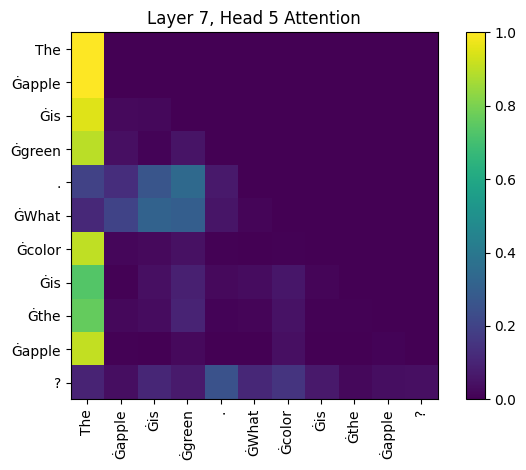

In [24]:
layer_idx = 6  #假設我們想觀察第 6 層 (layer_idx=5)
head_idx = 4  #假設我們想觀察第 7 個 Head (head_idx=6) 的注意力分佈 #可以把 6 改成其他數字，例如: 5,4,3

attn_matrix = attentions[layer_idx][0][head_idx].detach().cpu().numpy()
print(attn_matrix.shape, attn_matrix)

import matplotlib.pyplot as plt # Import matplotlib here
plt.imshow(attn_matrix, cmap="viridis")
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title(f"Layer {layer_idx+1}, Head {head_idx+1} Attention")
plt.colorbar()
plt.tight_layout()

#你會看到一個 L X L 的矩陣，嘗試解讀你看到了什麼? 為什麼右上角都是0

- 这张 11×11 的图就是“这 11 个 token 彼此之间的注意力”，行是 Query（当前位置在看谁），列是 Key（被看的人）。第 i 行是一整套概率分布，和≈1；右上角为 0 是因果 mask 的结果（不能看未来）。
- 右上角一大片 0，是因果(masked)自注意力的正常现象：decoder-only 模型（GPT 类）禁止每个位置“看见未来 token”。实现上是在 softmax 前把“未来”的 logits 加上 −∞（或非常大的负数），softmax 后这些位置就变成 0 概率，于是得到严格上三角为 0的注意力矩阵。
    - 如果是 BERT/encoder 自注意力或 cross-attention，通常不会是三角形；只有 decoder 自注意力才会出现这种形状。
- 第一列常见“竖条”高亮：很多 head 会偏好开头的 BOS/特殊符号当作全局锚点。
    - 即使没有显式 BOS，一些注意力头会学到一种**“全局锚”策略**：大量行把一定比例的权重投给最早的可见位置（位置 0，恰好是 “The”）。
    - 这在使用绝对位置或 RoPE 的解码器里经常出现：某些头泛化出“从句子开头收集全局语境/节奏”的功能。

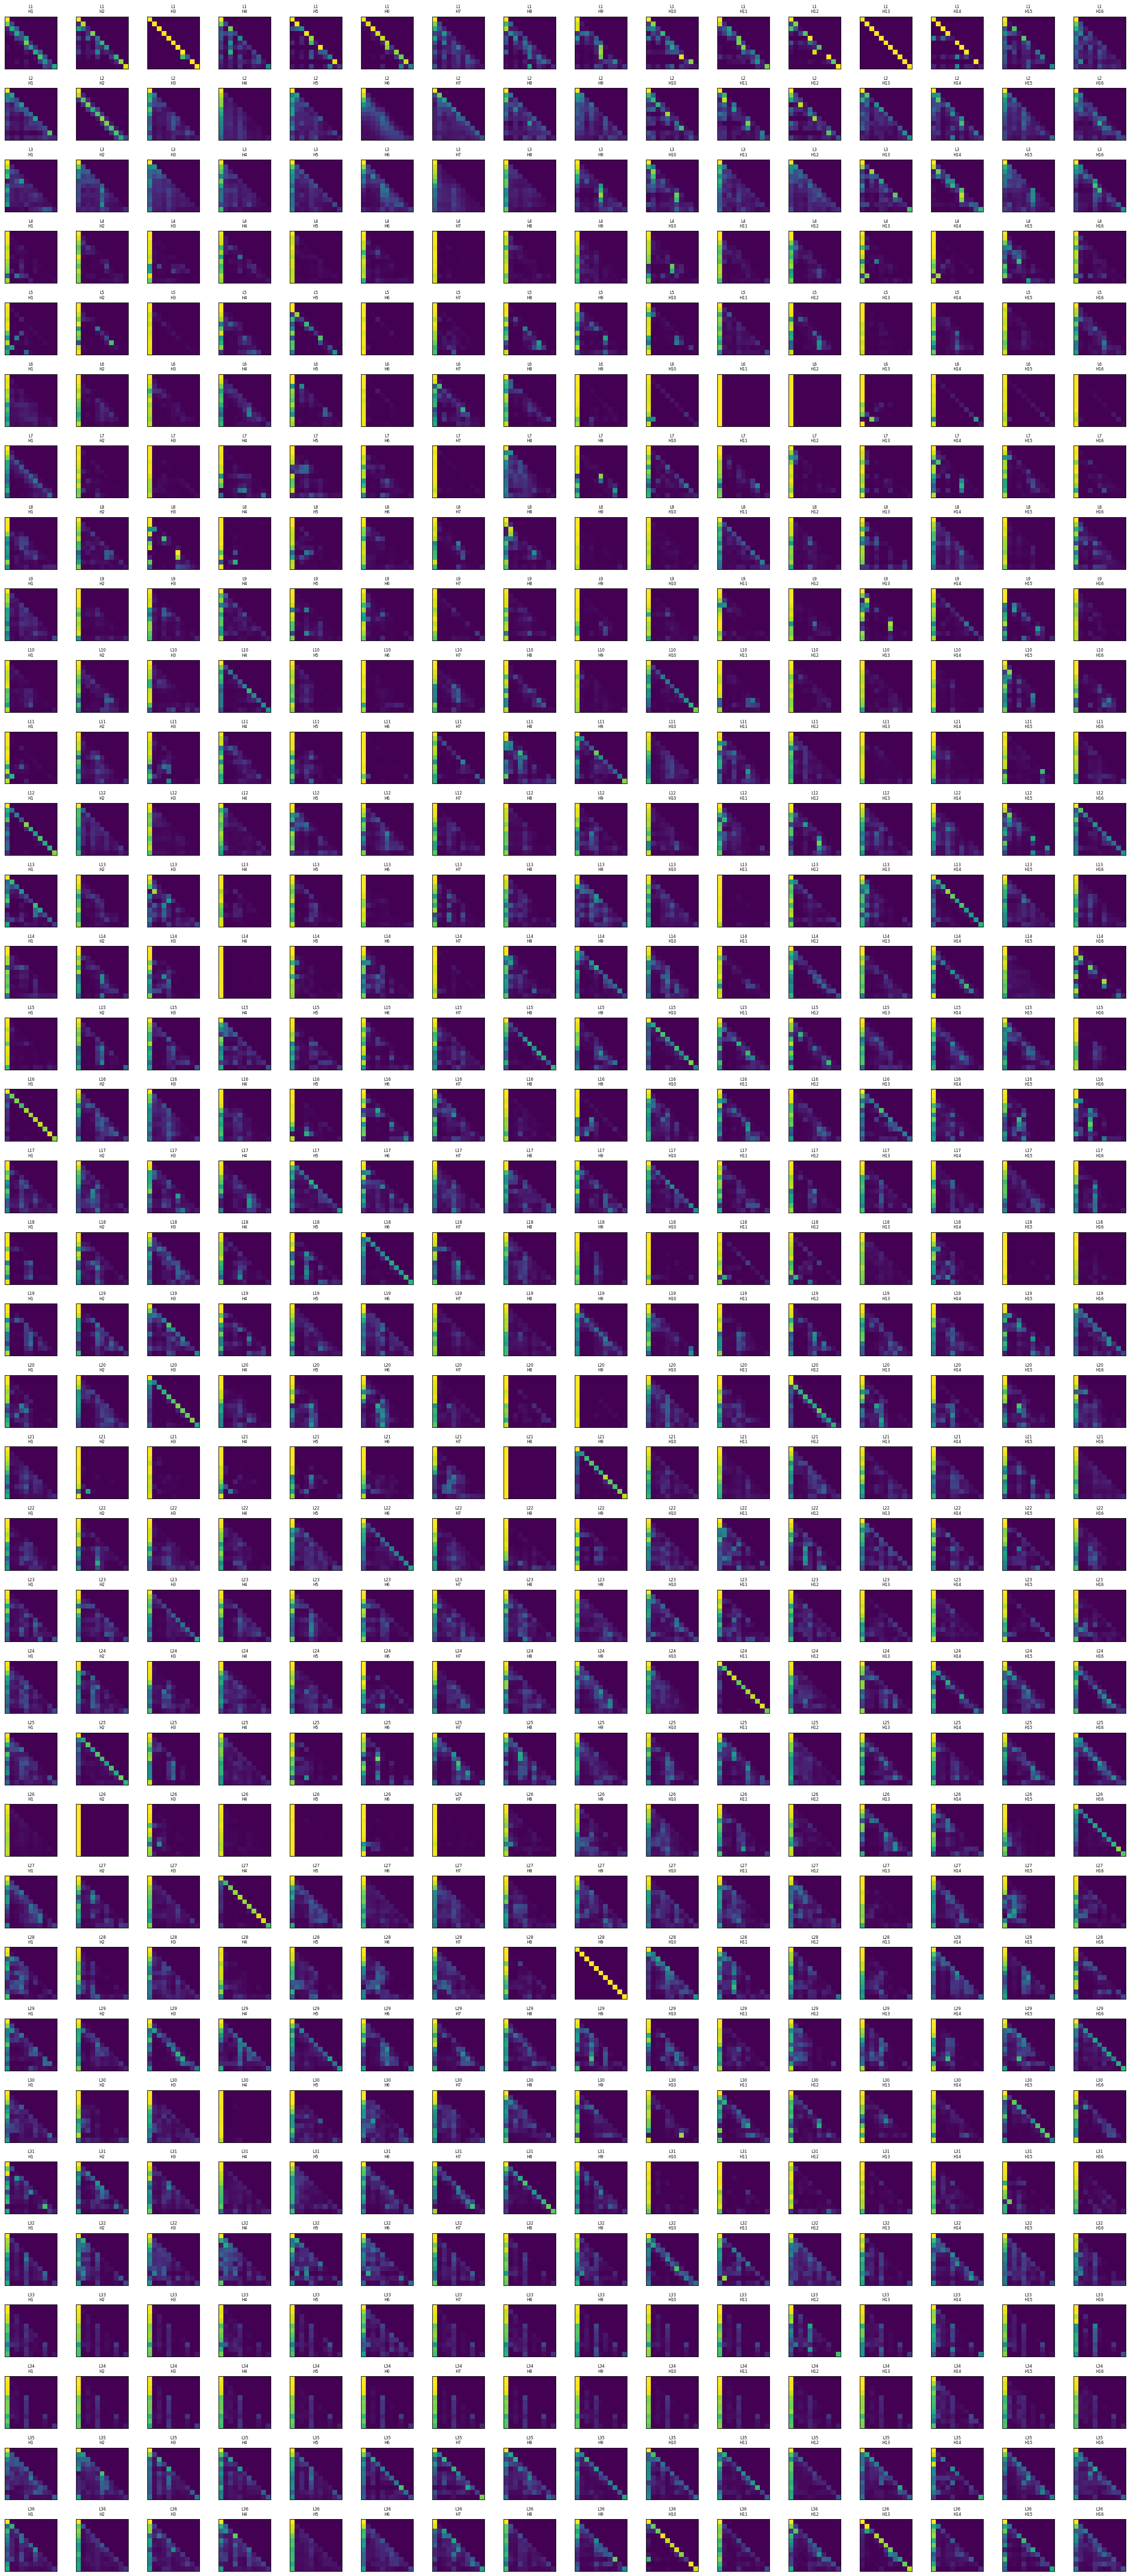

In [25]:
num_layers = len(attentions)
num_heads = attentions[0].shape[1]  # 每層 head 數

# 建立總圖
fig, axes = plt.subplots(num_layers, num_heads, figsize=(num_heads*1.5, num_layers*1.5))
if num_layers == 1 and num_heads == 1:
    axes = [[axes]]
elif num_layers == 1:
    axes = [axes]
elif num_heads == 1:
    axes = [[ax] for ax in axes]

# 畫每個子圖
for layer_idx in range(num_layers):
    for head_idx in range(num_heads):
        ax = axes[layer_idx][head_idx]
        attn_matrix = attentions[layer_idx][0, head_idx].detach().cpu().numpy()
        ax.imshow(attn_matrix, cmap="viridis")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"L{layer_idx+1}\nH{head_idx+1}", fontsize=6)

#plt.suptitle("Attention Maps (Layer × Head)", fontsize=14)
plt.tight_layout()